## Check DEV States

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from lerobot.envs.configs import LiberoEnv
from lerobot.envs import close_envs, make_env

/home/yjc1989/ML/robot-learning-project1/external/lerobot/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
PROJECT_ROOT = Path("~/ML/robot-learning-project1").expanduser()
DEV_STATES_PATH = (PROJECT_ROOT / "data/eval_init_states/libero_goal_bowl_plate_dev10.npy")
dev_states = np.load(DEV_STATES_PATH,allow_pickle=False)
dev_states.shape

(10, 79)

In [3]:
for i in range(dev_states.shape[0]):
    for j in range(i):
        assert np.sum(np.abs(dev_states[i] - dev_states[j])) > 1e-2

print("All developmental states are different!")

All developmental states are different!


In [4]:
LIBERO_SUITE = "libero_goal"
LIBERO_TASK_ID = 8

FPS = 20
MAX_EPISODE_STEPS = 300
EVAL_SEED = 1000

In [5]:
env_cfg = LiberoEnv(
    task=LIBERO_SUITE,
    task_ids=[LIBERO_TASK_ID],

    # Make all temporal assumptions explicit.
    fps=FPS,
    episode_length=MAX_EPISODE_STEPS,

    # Match NVIDIA demonstrations.
    observation_height=256,
    observation_width=256,

    obs_type="pixels_agent_pos",

    init_states=True,
    hard_reset=True,

    # Keep LeRobot's standard names here:
    # image + image2.
    # Our adapter will rename image2 -> wrist_image.
    camera_name_mapping={
        "agentview_image": "image",
        "robot0_eye_in_hand_image": "image2",
    },
)

envs = make_env(
    env_cfg,
    n_envs=1,
    use_async_envs=False,
)

env = envs[LIBERO_SUITE][LIBERO_TASK_ID]

libero_env = env.envs[0]

offcial_init_states = libero_env._init_states.copy()

print("Official init states:",libero_env._init_states.shape)

[robosuite WARNING] No private macro file found! (__init__.py:7)
[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)
[robosuite WARNING] To setup, run: python /home/yjc1989/ML/robot-learning-project1/external/lerobot/.venv/lib/python3.12/site-packages/robosuite/scripts/setup_macros.py (__init__.py:9)


Creating LIBERO envs | suites=['libero_goal'] | n_envs(per task)=1 | init_states=True
Restricting to task_ids=[8]
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Built vec env | suite=libero_goal | task_id=8 | n_envs=1
Official init states: (50, 79)


In [6]:
for i in range(offcial_init_states.shape[0]):
    for j in range(dev_states.shape[0]):
        assert np.sum(np.abs(offcial_init_states[i] - dev_states[j])) > 1e-2
print("All developmental states are different from the official_init_states!")

All developmental states are different from the official_init_states!


In [7]:
offcial_init_states[0]-dev_states[0]

array([ 0.        ,  0.01543739, -0.00991661, -0.01483789,  0.00985793,
        0.01646613, -0.00795325,  0.01164604,  0.        ,  0.        ,
        0.00412969, -0.01628376,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        , -0.01399455,  0.02160434,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.01054773,
       -0.01906955,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.02310411,  0.00421008,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.  

## Check Performance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from lerobot.envs.configs import LiberoEnv
from lerobot.envs import close_envs, make_env

/home/yjc1989/ML/robot-learning-project1/external/lerobot/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
PROJECT_ROOT = Path("~/ML/robot-learning-project1").expanduser()

In [3]:
def results_func(EXP_NAME, CHECKPOINT_LIST, MODE='dev'):
    MODEL_ROOT = (PROJECT_ROOT / f"results/{EXP_NAME}")
    df = pd.DataFrame()
    for CHECKPOINT in CHECKPOINT_LIST:
        df_temp = pd.read_csv(MODEL_ROOT/ f"evaluation/{MODE}_{CHECKPOINT}.csv")
        df = pd.concat([df, df_temp], ignore_index=True)

    df_agg = df.groupby(by="checkpoint").aggregate({"success":"mean"})
    return df, df_agg

In [4]:
EXP_NAME = "act_baseline3"
MODEL_ROOT = (PROJECT_ROOT / f"results/{EXP_NAME}")
CHECKPOINT = "000100"
MODE = 'dev'
df_temp = pd.read_csv(MODEL_ROOT/ f"evaluation/{MODE}_{CHECKPOINT}.csv")

In [5]:
df_temp[df_temp["success"]==False]["init_state_id"].to_list()

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

### ACT

In [6]:
EXP_NAME = "act_baseline3"
CHECKPOINT_LIST = ["000100","000200","000300","000400","000500","000600","000700","000800","000900","001000",
                   "002000","003000","004000","005000","006000","007000","008000","009000","010000"]
#CHECKPOINT_LIST = ["000100","000200","000300","000400","000500","000600","000700","000800","000900","001000",
#                   "002000","003000","004000","005000"]
df, df_agg = results_func(EXP_NAME, CHECKPOINT_LIST, MODE='dev')
df_test, df_test_agg = results_func(EXP_NAME, CHECKPOINT_LIST, MODE='test')

In [7]:
MODEL_ROOT = PROJECT_ROOT / f"results/{EXP_NAME}"
metrics = pd.read_csv(f"{MODEL_ROOT}/training_metrics.csv")
metrics2 = pd.read_csv(f"{MODEL_ROOT}/training_metrics2.csv")
metrics2["step"] = metrics2["step"] + 1000
metrics = pd.concat([metrics, metrics2])

In [8]:
df_out = pd.merge(df_test_agg.reset_index(), metrics, left_on='checkpoint', right_on = 'step',how='left')
df_out = df_out[["checkpoint", "success", "loss"]]
df_out.to_csv("../results/summary/ACT_results.csv")
print(df_out)

    checkpoint  success   loss
0          100     0.00  9.223
1          200     0.00  3.577
2          300     0.00  2.980
3          400     0.00  2.736
4          500     0.00  2.464
5          600     0.00  2.283
6          700     0.78  2.120
7          800     0.88  2.007
8          900     0.88  1.876
9         1000     0.96  1.792
10        2000     0.98  1.085
11        3000     0.98  0.681
12        4000     0.96  0.461
13        5000     0.98  0.347
14        6000     0.96  0.285
15        7000     0.98  0.247
16        8000     0.98  0.224
17        9000     0.94  0.201
18       10000     0.98  0.185


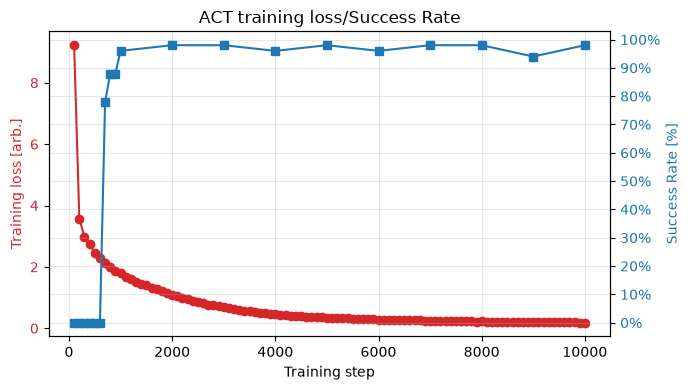

In [9]:
fig, ax1 = plt.subplots(figsize=(7, 4))
color = 'tab:red'
ax1.plot(metrics["step"], metrics["loss"], marker="o",color = color, label = "loss")
ax1.set_ylabel("Training loss [arb.]",color = color)
ax1.tick_params(axis='y', labelcolor=color)

ax1.set_xlabel("Training step")
ax1.set_title("ACT training loss/Success Rate")
ax1.grid(axis='x',alpha=0.3)


ax2 = ax1.twinx()
color = 'tab:blue'
#ax2.plot(df_agg.index, df_agg["success"], marker="X",color=color, linestyle = "--", label="SR_dev")
ax2.plot(df_test_agg.index, df_test_agg["success"], marker="s",color=color, label="SR_test")
ax2.set_ylabel('Success Rate [%]', color=color)  # we already handled the x-label with ax1
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_yticks(ticks=[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0],
               labels=["0%", "10%", "20%", "30%", "40%", "50%", "60%", "70%", "80%", "90%", "100%"])
#ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout() 
plt.savefig("../figures/act_LC.png")

In [9]:
for checkpoint in [1000,2000,3000,4000,5000,6000,7000,8000,9000,10000]:
    df_temp = df_test[df_test["checkpoint"] == checkpoint]
    fail_list=df_temp[df_temp["success"]==False]["init_state_id"].tolist()
    print(f"checkpoint = {checkpoint} with failure at {fail_list}")

checkpoint = 1000 with failure at [16, 40]
checkpoint = 2000 with failure at [41]
checkpoint = 3000 with failure at [0]
checkpoint = 4000 with failure at [23, 29]
checkpoint = 5000 with failure at [0]
checkpoint = 6000 with failure at [33, 34]
checkpoint = 7000 with failure at [33]
checkpoint = 8000 with failure at [5]
checkpoint = 9000 with failure at [9, 12, 45]
checkpoint = 10000 with failure at [49]


In [10]:
df_temp[df_temp["success"]][""]

KeyError: ''

In [11]:
EXP_NAME = "act_baseline3"
MODEL_ROOT = (PROJECT_ROOT / f"results/{EXP_NAME}")
CHECKPOINT = "010000"
MODE = 'test'
df_temp = pd.read_csv(MODEL_ROOT/ f"evaluation/{MODE}_{CHECKPOINT}_ana.csv")
df_temp.groupby("failure_mode").agg({"failure_mode": "count"})

,failure_mode
failure_mode,
transport,1


## Diffusion

In [10]:
PROJECT_ROOT = Path("~/ML/robot-learning-project1").expanduser()

EXP_NAME = "diffusion_baseline"
CHECKPOINT_LIST = ["000500","001000","001500","002000","002500","003000","003500","004000","004500","005000",
                   "006000","007000","008000","009000","010000", "011000", "012000", "013000", "014000", "015000"]
df, df_agg = results_func(EXP_NAME, CHECKPOINT_LIST, MODE='dev')
df_test, df_test_agg = results_func(EXP_NAME, CHECKPOINT_LIST, MODE='test')

In [11]:
MODEL_ROOT = PROJECT_ROOT / f"results/diffusion_baseline"
metrics = pd.read_csv(f"{MODEL_ROOT}/training_metrics.csv")

metrics2 = pd.read_csv(f"{MODEL_ROOT}/training_metrics2.csv")
metrics2["step"] = metrics2["step"] + 5000
metrics = pd.concat([metrics, metrics2])

metrics3 = pd.read_csv(f"{MODEL_ROOT}/training_metrics3.csv")
metrics3["step"] = metrics3["step"] + 10000
metrics = pd.concat([metrics, metrics3])

In [12]:
df_out = pd.merge(df_test_agg.reset_index(), metrics, left_on='checkpoint', right_on = 'step',how='left')
df_out = df_out[["checkpoint", "success", "loss"]]
df_out.to_csv("../results/summary/Diffusion_results.csv")
print(df_out)

    checkpoint  success   loss
0          500     0.00  0.100
1         1000     0.00  0.059
2         1500     0.02  0.047
3         2000     0.12  0.037
4         2500     0.36  0.043
5         3000     0.22  0.038
6         3500     0.44  0.030
7         4000     0.48  0.031
8         4500     0.84  0.026
9         5000     0.80  0.023
10        6000     0.38  0.026
11        7000     0.70  0.021
12        8000     0.86  0.016
13        9000     0.90  0.016
14       10000     0.94  0.012
15       11000     0.74  0.016
16       12000     0.92  0.014
17       13000     0.92  0.011
18       14000     0.98  0.010
19       15000     0.98  0.010


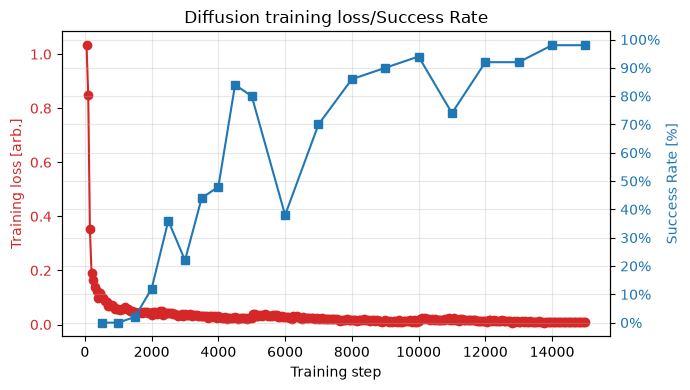

In [13]:
fig, ax1 = plt.subplots(figsize=(7, 4))
color = 'tab:red'
ax1.plot(metrics["step"], metrics["loss"], marker="o",color = color, label = "loss")
ax1.set_ylabel("Training loss [arb.]",color = color)
ax1.tick_params(axis='y', labelcolor=color)

ax1.set_xlabel("Training step")
ax1.set_title("Diffusion training loss/Success Rate")
ax1.grid(axis='x',alpha=0.3)


ax2 = ax1.twinx()
color = 'tab:blue'
#ax2.plot(df_agg.index, df_agg["success"], marker="X",color=color, linestyle = "--", label="SR_dev")
ax2.plot(df_test_agg.index, df_test_agg["success"], marker="s",color=color, label="SR_test")
ax2.set_ylabel('Success Rate [%]', color=color)  # we already handled the x-label with ax1
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_yticks(ticks=[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0],
               labels=["0%", "10%", "20%", "30%", "40%", "50%", "60%", "70%", "80%", "90%", "100%"])
#ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout() 
plt.savefig("../figures/diffusion_LC.png")

In [39]:
df_test_agg

,success
checkpoint,
500,0.00
1000,0.00
1500,0.02
2000,0.12
2500,0.36
3000,0.22
3500,0.44
4000,0.48
4500,0.84


In [40]:
EXP_NAME = "diffusion_baseline"
MODEL_ROOT = (PROJECT_ROOT / f"results/{EXP_NAME}")
CHECKPOINT = "010000"
MODE = 'test'
df_temp = pd.read_csv(MODEL_ROOT/ f"evaluation/{MODE}_{CHECKPOINT}_ana.csv")
df_temp.groupby("failure_mode").agg({"failure_mode": "count"})

,failure_mode
failure_mode,
grasp,2
transport,1


### SmolVLA

In [14]:
EXP_NAME = "smolvla_lora_baseline"
CHECKPOINT_LIST = ["000500","001000","001500","002000","002500","003000","003500","004000","004500","005000"]
df, df_agg = results_func(EXP_NAME, CHECKPOINT_LIST, MODE='dev')
df_test, df_test_agg = results_func(EXP_NAME, CHECKPOINT_LIST, MODE='test')

In [15]:
MODEL_ROOT = PROJECT_ROOT / f"results/{EXP_NAME}"
metrics = pd.read_csv(f"{MODEL_ROOT}/training_metrics.csv")

In [16]:
df_out = pd.merge(df_test_agg.reset_index(), metrics, left_on='checkpoint', right_on = 'step',how='left')
df_out = df_out[["checkpoint", "success", "loss"]]
df_out.to_csv("../results/summary/SmolVLA_results.csv")
print(df_out)

   checkpoint  success   loss
0         500     0.14  0.512
1        1000     0.40  0.413
2        1500     0.94  0.377
3        2000     0.90  0.344
4        2500     0.80  0.334
5        3000     0.88  0.318
6        3500     0.88  0.298
7        4000     0.96  0.284
8        4500     0.94  0.277
9        5000     0.94  0.275


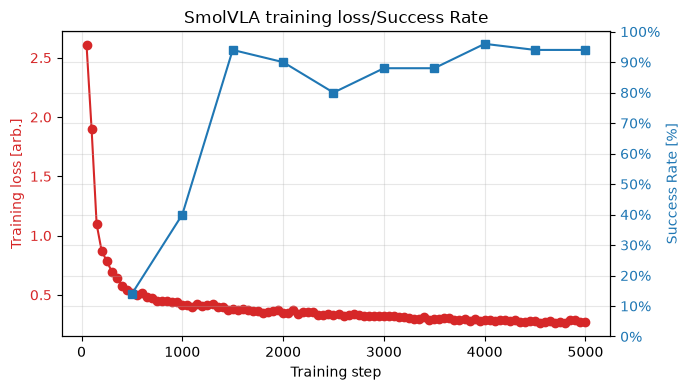

In [17]:
fig, ax1 = plt.subplots(figsize=(7, 4))
color = 'tab:red'
ax1.plot(metrics["step"], metrics["loss"], marker="o",color = color, label = "loss")
ax1.set_ylabel("Training loss [arb.]",color = color)
ax1.tick_params(axis='y', labelcolor=color)

ax1.set_xlabel("Training step")
ax1.set_title("SmolVLA training loss/Success Rate")
ax1.grid(axis='x',alpha=0.3)



ax2 = ax1.twinx()
color = 'tab:blue'
#ax2.plot(df_agg.index, df_agg["success"], marker="X",color=color, linestyle = "--", label="SR_dev")
ax2.plot(df_test_agg.index, df_test_agg["success"], marker="s",color=color, label="SR_test")
ax2.set_ylabel('Success Rate [%]', color=color)  # we already handled the x-label with ax1
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_yticks(ticks=[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0],
               labels=["0%", "10%", "20%", "30%", "40%", "50%", "60%", "70%", "80%", "90%", "100%"])
ax2.grid(alpha=0.3)
#ax2.legend()

plt.tight_layout() 
plt.savefig("../figures/smolvla_LC.png")

In [17]:
df_test_agg

,success
checkpoint,
500,0.14
1000,0.40
1500,0.94
2000,0.90
2500,0.80
3000,0.88
3500,0.88
4000,0.96
4500,0.94


In [35]:
EXP_NAME = "smolvla_lora_baseline"
MODEL_ROOT = (PROJECT_ROOT / f"results/{EXP_NAME}")
CHECKPOINT = "005000"
MODE = 'test'
df_temp = pd.read_csv(MODEL_ROOT/ f"evaluation/{MODE}_{CHECKPOINT}_ana.csv")
df_temp.groupby("failure_mode").agg({"failure_mode": "count"})

,failure_mode
failure_mode,
grasp,1
transport,2


In [19]:
df_temp

,policy,experiment_name,checkpoint,task,init_state_id,seed,success,steps,failure_mode
0,SmolVLA,smolvla_lora_baseline,2000,8,0,1000,False,300,recovery
1,SmolVLA,smolvla_lora_baseline,2000,8,1,1000,True,152,NaN
2,SmolVLA,smolvla_lora_baseline,2000,8,2,1000,True,80,NaN
3,SmolVLA,smolvla_lora_baseline,2000,8,3,1000,True,71,NaN
4,SmolVLA,smolvla_lora_baseline,2000,8,4,1000,True,86,NaN
5,SmolVLA,smolvla_lora_baseline,2000,8,5,1000,True,139,NaN
6,SmolVLA,smolvla_lora_baseline,2000,8,6,1000,True,84,NaN
7,SmolVLA,smolvla_lora_baseline,2000,8,7,1000,True,69,NaN
8,SmolVLA,smolvla_lora_baseline,2000,8,8,1000,True,56,NaN
9,SmolVLA,smolvla_lora_baseline,2000,8,9,1000,True,85,NaN


,failure_mode
failure_mode,
grasp,35
placement,6
transport,2
